In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

from data_loader import build_merged_dataset, preprocess_merged_df
from lstm_utils import (
    LstmFeatureProcessor,
    LstmTargetProcessor,
    LstmFactorAnalyzer,
    rolling_zscore_matrix
)
from backtesting import (
    get_tanh_signal,
    backtest_strategy,
    plot_trade_signals,
    plot_backtest_strategy
)


In [3]:
# 与 LSTM 完全对齐
TEST_DAYS     = 14        # 最后 14 天用来预测 + 回测
TARGET_WINDOW = 30        # 预测未来 30 分钟累计 log return
ROLLING_WINDOW = 60
TARGET_SCALE   = 100


In [4]:
# 1) 以 BTC 为主时间轴合并多资产
raw_df = build_merged_dataset(
    btc_path="data/btcusd_1-min_data.csv",
    eth_path="data/ETH_USD_1min_2020_2025.csv",
    eur_path="data/EUR_USD_1min_2020_2025.csv",
    gld_path="data/GLD_1min_2020_2025.csv",
    spy_path="data/SPY_1min_2020_2025.csv",
    vixy_path="data/VIXY_1min_2020_2025.csv",
)

# 2) ETH/EUR 插值 + mask + US_Trading_Hours
df = preprocess_merged_df(raw_df)

print("Merged shape:", df.shape)
print(df.head())


Loading CSV files...
Aligning to BTC 7x24 timeline...
Merging all assets...
Adding US market trading hours flag...
Done! Final shape: (368618, 29)
Merged shape: (368618, 34)
                              Open     High      Low    Close    Volume  \
Timestamp                                                                 
2025-01-01 00:00:00-05:00  93355.0  93355.0  93345.0  93345.0  0.538318   
2025-01-01 00:01:00-05:00  93390.0  93392.0  93390.0  93392.0  0.005664   
2025-01-01 00:02:00-05:00  93387.0  93387.0  93376.0  93376.0  1.386846   
2025-01-01 00:03:00-05:00  93379.0  93379.0  93377.0  93377.0  0.005737   
2025-01-01 00:04:00-05:00  93375.0  93376.0  93375.0  93376.0  0.111288   

                           ETH/USD_open  ETH/USD_high  ETH/USD_low  \
Timestamp                                                            
2025-01-01 00:00:00-05:00       3340.49       3340.56      3340.44   
2025-01-01 00:01:00-05:00       3342.38       3343.25      3341.39   
2025-01-01 00:02:00-

In [5]:
# 3) LSTM 同款特征工程
lstmfp = LstmFeatureProcessor(rolling_smooth=ROLLING_WINDOW)
df_feat = lstmfp.process_all(df)
feature_cols = lstmfp.get_feature_columns(df_feat)

print("Feature-engineered shape:", df_feat.shape)


Feature-engineered shape: (366582, 133)


In [6]:
# 4) Target 构造（未来 30min 累计 log return）+ 波动率归一化 + RobustScaler
lstmtp = LstmTargetProcessor(price_col='Close', window=TARGET_WINDOW)
btc, norm_cols = lstmtp.fit_transform(df_feat)

# 保留 1min log return、30min 累计 return、binary 三个目标
target_cols = ['target_log_return', f'target_cum_return_{TARGET_WINDOW}m', 'target_binary']

# 丢掉特征/target 有 NaN 的行
btc = btc.dropna(subset=feature_cols + target_cols)
print("After target processing & dropna:", btc.shape)


After target processing & dropna: (366552, 138)


In [7]:
# 5) 按时间切分，先在训练段做因子选择，防止 lookahead bias
test_len    = TEST_DAYS * 1440
split_index = len(btc) - test_len

train_df = btc.iloc[:split_index]
test_df  = btc.iloc[split_index:]

print("Train_df shape:", train_df.shape)
print("Test_df shape:", test_df.shape)

# 在 train_df 上做因子分析，只用训练段的信息
lstmanalyzer = LstmFactorAnalyzer(
    df=train_df,
    feature_cols=feature_cols,
    target_col=f'target_cum_return_{TARGET_WINDOW}m_norm'
)

selected_features, metrics_df = lstmanalyzer.run_full_analysis(
    ic_threshold=0.015,
    mi_threshold=0.01,
    corr_threshold=0.2,
    top_n=60
)
print("Selected features:", len(selected_features))
# lstmanalyzer.plot_analysis(metrics_df, selected_features)  # 需要可视化时再画


Train_df shape: (346392, 138)
Test_df shape: (20160, 138)
Factor Analyzer Initialized. Samples: 346392
   -> Calculating IC & ICIR...


c:\Users\Owner\anaconda3\envs\BUMF703\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\BU MSMFT\MF703\project\bitcoin\xgboost final\lstm_utils.py:314: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  g_ic, _ = spearmanr(self.clean_df[feature], self.clean_df[self.target])
c:\BU MSMFT\MF703\project\bitcoin\xgboost final\lstm_utils.py:314: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  g_ic, _ = spearmanr(self.clean_df[feature], self.clean_df[self.target])
c:\BU MSMFT\MF703\project\bitcoin\xgboost final\lstm_utils.py:314: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  g_ic, _ = spearmanr(self.clean_df[feature], self.clean_df[self.target])
c:\BU MSMFT\MF703\project\bitcoin\xgboost final\lstm_utils.py:314: ConstantInputWarning: An inp

   -> Calculating Mutual Information (Non-linear dependency)...
   -> Features passing signal threshold: 72 / 133
   -> Removing redundant features (Threshold > 0.2)...
      Dropped 65 redundant features.
Final Selected Features: 7
Selected features: 7


In [8]:
FEATURES_CONT = selected_features
FEATURES_CAT  = ['US_Trading_Hours']

print(f"Applying Rolling Z-Score (window={ROLLING_WINDOW})...")
X_cont_scaled = rolling_zscore_matrix(btc, FEATURES_CONT, window=ROLLING_WINDOW)
X_cat         = btc[FEATURES_CAT].loc[X_cont_scaled.index].copy()

X = pd.concat([X_cont_scaled, X_cat], axis=1)
X = X.replace([np.inf, -np.inf], 0).fillna(0)

y = btc[f'target_cum_return_{TARGET_WINDOW}m_norm'].copy()
y = y.loc[X.index]
y = y * TARGET_SCALE  # 和 LSTM 完全一样的缩放

print("-" * 40)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features used:", len(X.columns))
print("-" * 40)


Applying Rolling Z-Score (window=60)...
----------------------------------------
X shape: (366493, 8)
y shape: (366493,)
Features used: 8
----------------------------------------


In [9]:
TEST_DAYS = 14
test_len    = TEST_DAYS * 1440
split_index = len(X) - test_len

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]

print("-" * 40)
print("Train X:", X_train.shape, "Train y:", y_train.shape)
print("Test  X:", X_test.shape,  "Test  y:", y_test.shape)
print(f"Test window ~ {TEST_DAYS} days")
print("-" * 40)


----------------------------------------
Train X: (346333, 8) Train y: (346333,)
Test  X: (20160, 8) Test  y: (20160,)
Test window ~ 14 days
----------------------------------------


In [10]:
param_space = {
    'n_estimators':      [200, 400, 600, 800],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.03, 0.05, 0.1],
    'subsample':         [0.6, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.8, 1.0],
    'min_child_weight':  [1, 3, 5],
    'gamma':             [0.0, 0.1, 0.3],
    'reg_lambda':        [1.0, 3.0, 5.0],
    'reg_alpha':         [0.0, 0.1, 0.5],
}

num_trials = 30   # 你可以根据算力调整
results = []

best_rmse   = float('inf')
best_params = None
best_model  = None

print("Starting XGBoost Random Search ...")

for i in range(num_trials):
    # 随机抽取一组超参数
    params = {k: random.choice(v) for k, v in param_space.items()}
    print(f"\n--- Trial {i+1}/{num_trials} ---")
    print("Params:", params)

    model = XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        n_jobs=-1,
        **params
    )

    model.fit(X_train, y_train)

    # 在最后 14 天（测试段）上评估
    y_test_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    print(f"Validation RMSE (last {TEST_DAYS} days): {rmse:.5f}")

    results.append({**params, 'rmse': rmse})

    if rmse < best_rmse:
        best_rmse   = rmse
        best_params = params
        best_model  = model
        print(f"  -> New best model with RMSE = {best_rmse:.5f}")

# 汇总结果
results_df = pd.DataFrame(results).sort_values(by='rmse')
print("\nTop 5 hyperparameter combinations:")
print(results_df.head())

print("\nBest overall params:", best_params)
print("Best overall RMSE:", best_rmse)


Starting XGBoost Random Search ...

--- Trial 1/30 ---
Params: {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.1, 'reg_lambda': 5.0, 'reg_alpha': 0.0}
Validation RMSE (last 14 days): 89.42451
  -> New best model with RMSE = 89.42451

--- Trial 2/30 ---
Params: {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 1.0, 'colsample_bytree': 0.6, 'min_child_weight': 1, 'gamma': 0.3, 'reg_lambda': 1.0, 'reg_alpha': 0.5}
Validation RMSE (last 14 days): 88.36027
  -> New best model with RMSE = 88.36027

--- Trial 3/30 ---
Params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'gamma': 0.1, 'reg_lambda': 3.0, 'reg_alpha': 0.0}
Validation RMSE (last 14 days): 87.92777
  -> New best model with RMSE = 87.92777

--- Trial 4/30 ---
Params: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.03, 'subsample': 

In [11]:
# 使用最优模型
FINAL_XGB_MODEL = best_model

# ① 在整个测试段上先预测
y_test_pred_full = FINAL_XGB_MODEL.predict(X_test)
y_test_full      = y_test.values

# ② 为了和 LSTM 对齐，丢掉测试段前 SEQ_LEN 分钟
SEQ_LEN = 60  # 和 LSTM 最终使用的一致（从 lstm_outputs.csv 推出来的）

y_test_pred = y_test_pred_full[SEQ_LEN:]
y_test_true = y_test_full[SEQ_LEN:]

print("Effective test samples (after dropping first 60 mins):", len(y_test_true))


Effective test samples (after dropping first 60 mins): 20100


In [12]:
# 按 LSTM 的顺序：先 *TARGET_SCALE, 再逆 RobustScaler, 再乘波动率
scaler_center = lstmtp.scaler.center_[1]  # 对应 target_cum_return_30m_norm 的 center
scaler_scale  = lstmtp.scaler.scale_[1]   # 对应该列的 scale

# 用最后 len(y_test_pred) 个波动率，与 LSTM 一致
val_vol = lstmtp.volatility.values[-len(y_test_pred):]

# 1) 逆 TARGET_SCALE
y_pred_1 = y_test_pred * TARGET_SCALE
y_true_1 = y_test_true * TARGET_SCALE

# 2) 逆 RobustScaler
y_pred_2 = y_pred_1 * scaler_scale + scaler_center
y_true_2 = y_true_1 * scaler_scale + scaler_center

# 3) 乘回波动率，得到“真实尺度”的 30min 累计 log return
real_y_pred = y_pred_2 * val_vol
real_y_true = y_true_2 * val_vol

print(f"Range of True Return: Min {real_y_true.min():.5f}, Max {real_y_true.max():.5f}")
print(f"Range of Pred Return: Min {real_y_pred.min():.5f}, Max {real_y_pred.max():.5f}")


Range of True Return: Min -290.60992, Max 257.90794
Range of Pred Return: Min -25.46744, Max 19.86967


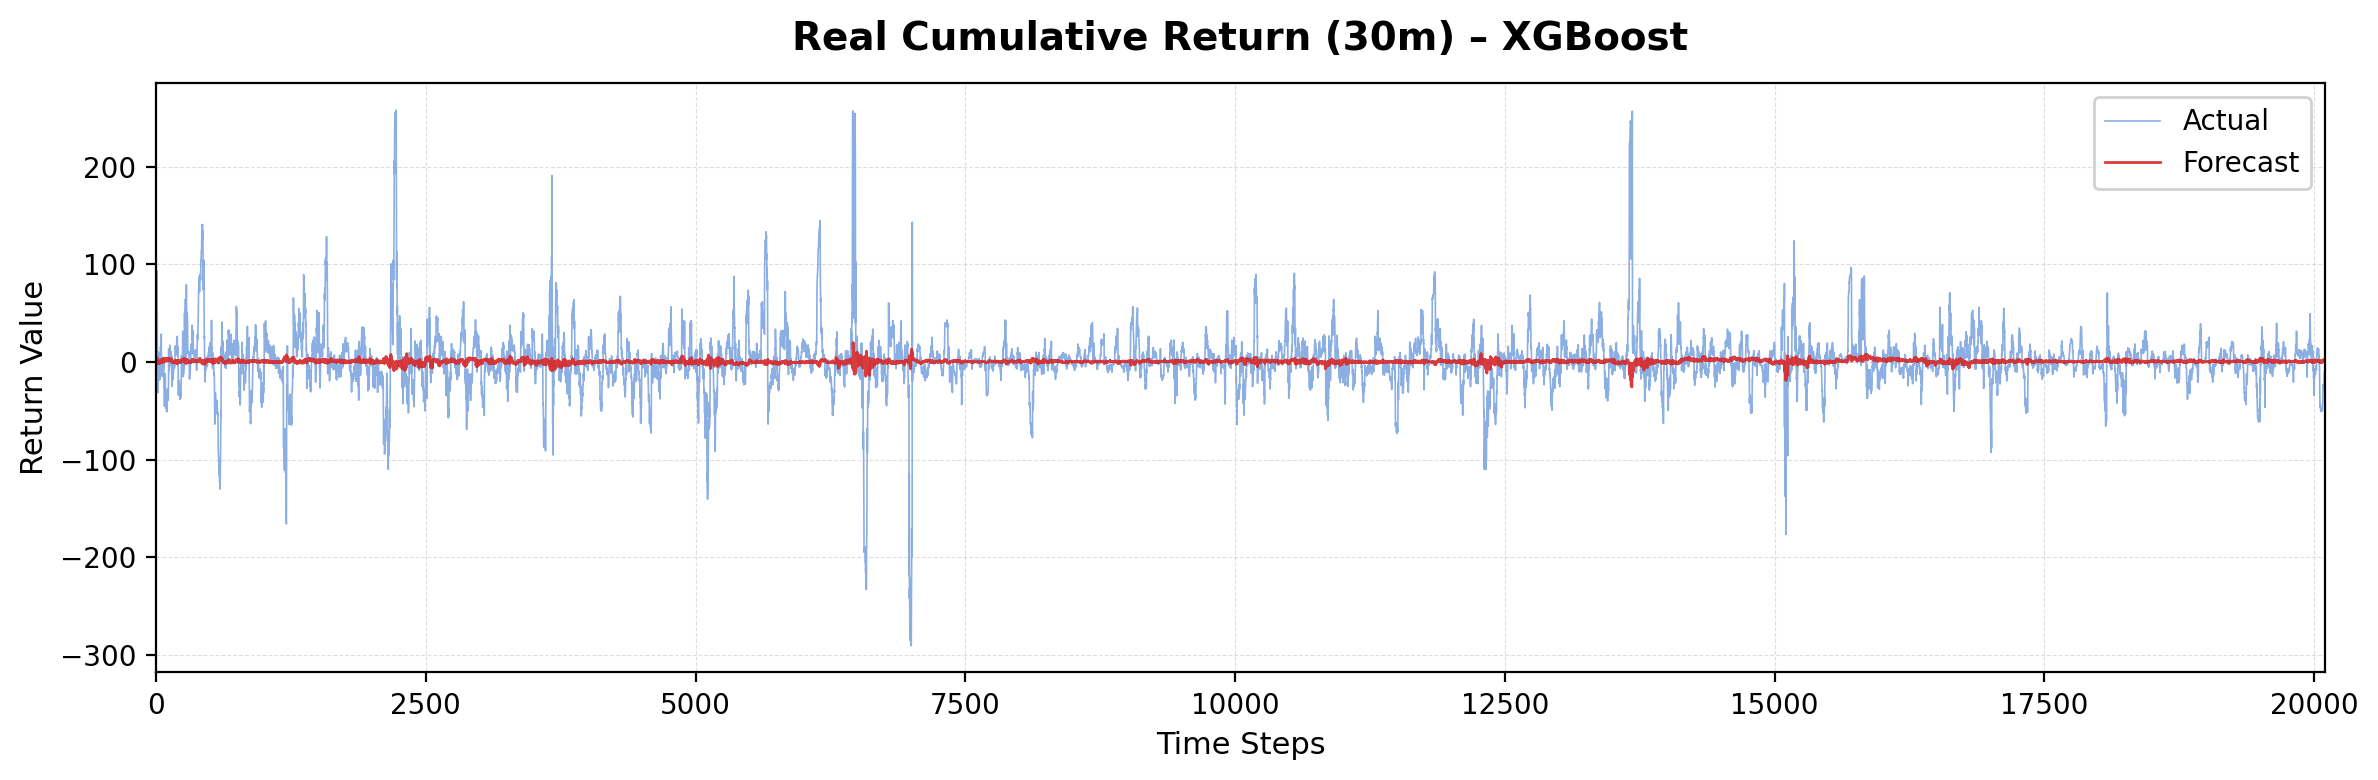

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def plot_real_vs_forecast_cum_return(real_cum_return,
                                     forecast_cum_return,
                                     title="Real Cumulative Return (30m)"):
    """
    real_cum_return      : 1D array-like, 实际累计收益
    forecast_cum_return  : 1D array-like, 预测累计收益（由模型输出累加而成）
    """

    real_cum_return = np.asarray(real_cum_return)
    forecast_cum_return = np.asarray(forecast_cum_return)
    assert real_cum_return.shape == forecast_cum_return.shape, \
        "real_cum_return 和 forecast_cum_return 长度必须一致"

    time_steps = np.arange(len(real_cum_return))

    # 画图风格尽量贴近你 PPT 里的那张图
    plt.figure(figsize=(12, 4), dpi=200)

    # 实际曲线（淡蓝色，细线，略有透明度）
    plt.plot(
        time_steps,
        real_cum_return,
        color="#7EA6E0",      # 浅蓝
        linewidth=0.6,
        alpha=0.9,
        label="Actual"
    )

    # 预测曲线（红色，稍粗一点）
    plt.plot(
        time_steps,
        forecast_cum_return,
        color="#D62728",      # 红色
        linewidth=1.0,
        alpha=0.9,
        label="Forecast"
    )

    # 轴标签、标题
    plt.title(title, fontsize=14, fontweight="bold", pad=12)
    plt.xlabel("Time Steps", fontsize=11)
    plt.ylabel("Return Value", fontsize=11)

    # 网格和边框，和 PPT 风格类似
    plt.grid(True, linestyle="--", linewidth=0.4, alpha=0.4)
    ax = plt.gca()
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.spines["left"].set_visible(True)

    # legend 放在右上角
    plt.legend(loc="upper right", fontsize=10, frameon=True, framealpha=0.9)

    # x 轴尽量显示首尾
    plt.xlim(time_steps[0], time_steps[-1])

    # 让布局紧凑一点，和 PPT 里的图片比例接近
    plt.tight_layout()
    plt.show()
plot_real_vs_forecast_cum_return(
    real_cum_return=real_y_true,       # 实际累计收益（真实尺度 30m 累计 log return）
    forecast_cum_return=real_y_pred,   # XGBoost 预测的累计收益
    title="Real Cumulative Return (30m) – XGBoost"
)

 Scale Factor: 0.61 (based on data stddev)
------------------------------
Signal Range: [-1.0000, 1.0000]
Signal Mean:  0.1754
Signal Std:   0.5191
------------------------------


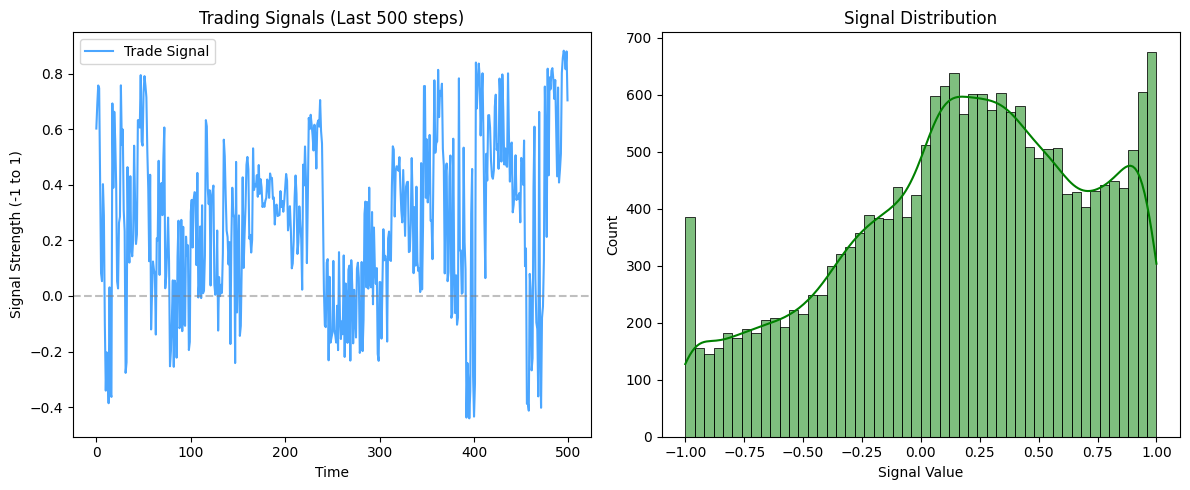

In [13]:
signals = get_tanh_signal(real_y_pred)
plot_trade_signals(signals, last_n=500)


In [14]:
num_test_samples = len(signals)
real_step_returns = btc['target_log_return'].iloc[-num_test_samples:].values
real_step_returns = np.nan_to_num(real_step_returns)

print(f"Length of signals: {len(signals)}")
print(f"Length of real_step_returns: {len(real_step_returns)}")
print(f"Test length (days): {len(signals) / 60 / 24:.2f}")


Length of signals: 20100
Length of real_step_returns: 20100
Test length (days): 13.96


In [19]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

mse = mean_squared_error(real_y_true, real_y_pred)
mae = mean_absolute_error(real_y_true, real_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(real_y_true, real_y_pred)

signal_true = np.sign(real_y_true)
signal_pred = np.sign(real_y_pred)
valid_mask = signal_true != 0
win_rate = (signal_true[valid_mask] == signal_pred[valid_mask]).mean()

print(f"MSE      : {mse:.6f}")
print(f"MAE      : {mae:.6f}")
print(f"RMSE     : {rmse:.6f}")
print(f"R^2 Score: {r2:.6f}")
print(f"Win Rate : {win_rate*100:.2f}%")

MSE      : 911.628397
MAE      : 16.792088
RMSE     : 30.193185
R^2 Score: -0.013836
Win Rate : 52.05%



📊 Strategy Performance Comparison (Last 14 Days (XGBoost))
Metric                 | Thresh=0.0, Cost=0.0 | Thresh=0.6, Cost=0.0001
-------------------------------------------------------------------------------------
Total Return (B&H)     | 7.06%              | 7.06%             
Total Return (Strat)   | 4.12%              | -26.07%           
Sharpe Ratio           | 5.62               | -44.46            
Sortino Ratio          | 6.17               | -37.84            
Max Drawdown           | -2.72%             | -26.17%           
Trade Count            | 20100              | 8539              
Cost Rate              | 0.00%              | 0.01%             


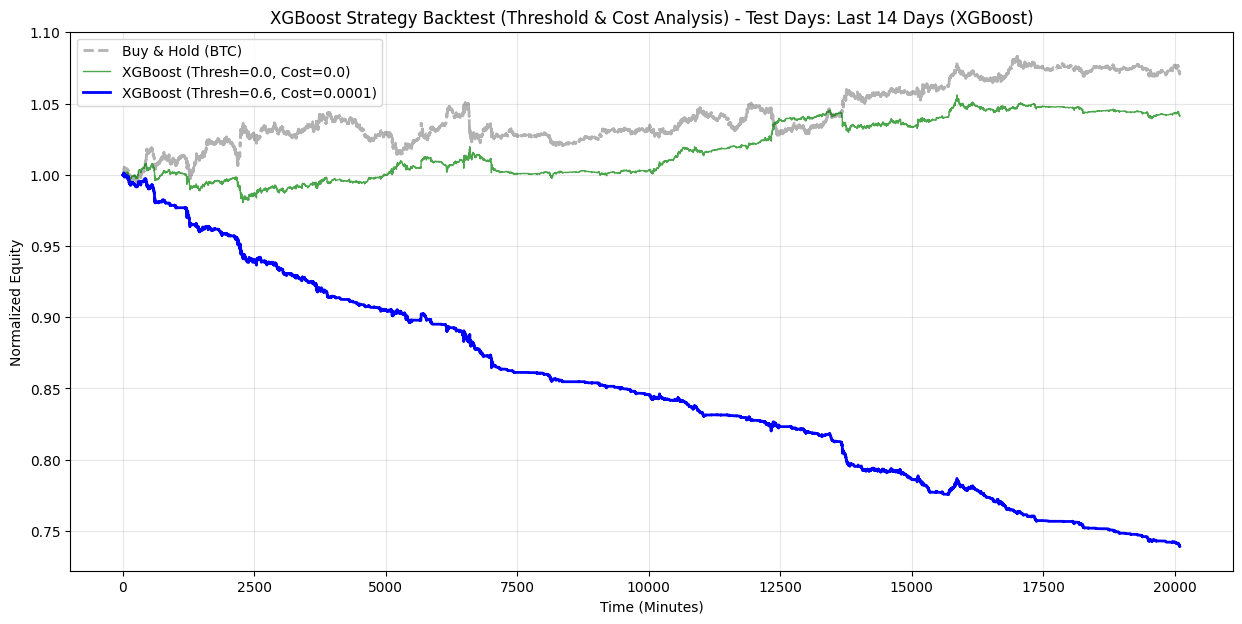

In [15]:
# 情景 1：现实情景（阈值 0.6，成本 0.01%）
res_real = backtest_strategy(signals, real_step_returns,
                             threshold=0.6, cost_rate=0.0001)

# 情景 2：理想情景（0 阈值、0 成本）
res_ideal = backtest_strategy(signals, real_step_returns,
                              threshold=0.0, cost_rate=0.0)

# 画对比曲线（这里可以复用 LSTM 的函数，但注意图里的标签会写 LSTM；
# 如果介意，你也可以复制一份函数，把 label 改成 XGBoost）
plot_backtest_strategy(
    signals=signals,
    returns=real_step_returns,
    thresholds=[0.0, 0.6],
    cost_rates=[0.0, 0.0001],
    test_days='Last 14 Days (XGBoost)'
)


In [17]:
'''xgb_save_df = pd.DataFrame({
    "y_true": real_y_true,                  # 和 LSTM 定义一致
    "y_pred": real_y_pred,                  # XGBoost 预测的“真实尺度” 30min 累计 log ret
    "signals": signals,                     # 由 real_y_pred 映射得到的交易信号
    "benchmark": res_ideal["equity_bh"],    # BTC 买入持有权益曲线
    "xgb_cum_return_ideal": res_ideal["equity_strat"],  # 无阈值、无成本
    "xgb_cum_return_real": res_real["equity_strat"]     # 阈值 0.6、成本 0.01%
})

xgb_save_df.to_csv("xgb_outputs.csv", index=False)
print("Saved: xgb_outputs.csv")
'''

'xgb_save_df = pd.DataFrame({\n    "y_true": real_y_true,                  # 和 LSTM 定义一致\n    "y_pred": real_y_pred,                  # XGBoost 预测的“真实尺度” 30min 累计 log ret\n    "signals": signals,                     # 由 real_y_pred 映射得到的交易信号\n    "benchmark": res_ideal["equity_bh"],    # BTC 买入持有权益曲线\n    "xgb_cum_return_ideal": res_ideal["equity_strat"],  # 无阈值、无成本\n    "xgb_cum_return_real": res_real["equity_strat"]     # 阈值 0.6、成本 0.01%\n})\n\nxgb_save_df.to_csv("xgb_outputs.csv", index=False)\nprint("Saved: xgb_outputs.csv")\n'